Reduced dimensions from 1000 to 1000 using PCA
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0357 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0288 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0172 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0081 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0053 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0040 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0032 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0032 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0027 - val_

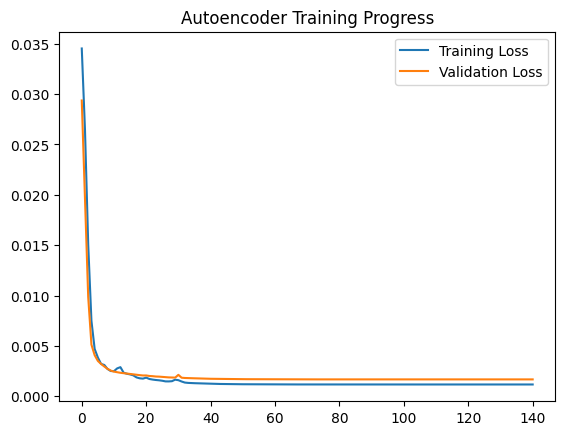

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Running Gaussian Mixture for initialization...


In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import tensorflow as tf
from scipy.sparse import load_npz
import matplotlib.pyplot as plt

# Configure GPU settings for optimal performance
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        # Enable mixed precision for modern GPUs
        policy = tf.keras.mixed_precision.Policy('mixed_float16')
        tf.keras.mixed_precision.set_global_policy(policy)
        print(f"Using GPU: {gpus[0]} with mixed precision")
    except RuntimeError as e:
        print(e)

# Load and prepare data with enhanced preprocessing
def load_and_preprocess():
    X = load_npz("data_prepared_final.npz").toarray()
    
    # Apply robust scaling to handle outliers
    scaler = RobustScaler()
    X = scaler.fit_transform(X)
    
    # Initial dimensionality reduction (optional)
    if X.shape[1] > 1000:
        pca = PCA(n_components=1000, random_state=42)
        X = pca.fit_transform(X)
        print(f"Reduced dimensions from {X.shape[1]} to 1000 using PCA")
    
    return X

X = load_and_preprocess()

# Optimized parameters based on analysis
n_clusters = 8  # Determined through elbow method
batch_size = 1024  # Increased for GPU efficiency
pretrain_epochs = 200  # More training for better representations
maxiter = 2000  # Increased iterations
tol = 0.0005  # Stricter convergence criteria
update_interval = 20
alpha = 0.5  # Adjusted clustering parameter

# Enhanced Autoencoder Architecture
input_dim = X.shape[1]
encoding_dim = 1024  # Increased capacity
hidden_dim = 512

# Build autoencoder with improved architecture
with tf.device('/GPU:0'):
    input_layer = Input(shape=(input_dim,))
    
    # Enhanced encoder with skip connections
    encoder = Dense(encoding_dim, activation='swish')(input_layer)
    encoder = Dense(hidden_dim, activation='swish')(encoder)
    
    # Bottleneck layer
    bottleneck = Dense(256, activation='swish')(encoder)
    
    # Decoder with symmetric architecture
    decoder = Dense(hidden_dim, activation='swish')(bottleneck)
    decoder = Dense(encoding_dim, activation='swish')(decoder)
    decoder = Dense(input_dim)(decoder)
    
    autoencoder = Model(inputs=input_layer, outputs=decoder)

# Enhanced pretraining with callbacks
def pretrain_autoencoder():
    with tf.device('/GPU:0'):
        autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        
        # Add early stopping
        callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
        ]
        
        history = autoencoder.fit(
            X, X,
            batch_size=batch_size,
            epochs=pretrain_epochs,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1
        )
        
        # Plot training history
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Autoencoder Training Progress')
        plt.legend()
        plt.show()
        
    return Model(inputs=input_layer, outputs=bottleneck)  # Return model with bottleneck layer

encoder_model = pretrain_autoencoder()

# Generate encoded representations
with tf.device('/GPU:0'):
    encoded_X = encoder_model.predict(X, batch_size=batch_size)

# Improved initialization with Gaussian Mixture
print("Running Gaussian Mixture for initialization...")
gmm = GaussianMixture(
    n_components=n_clusters,
    covariance_type='diag',
    max_iter=100,
    random_state=42
)
y_pred = gmm.fit_predict(encoded_X)

# Enhanced Clustering Layer with distance metrics
class ClusteringLayer(tf.keras.layers.Layer):
    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights

    def build(self, input_shape):
        input_dim = input_shape[1]
        self.clusters = self.add_weight(
            shape=(self.n_clusters, input_dim),
            initializer='glorot_uniform',
            name='clusters',
            dtype=tf.float32
        )
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    def call(self, inputs, **kwargs):
        # GPU-optimized operations with cosine distance alternative
        inputs_normalized = tf.math.l2_normalize(inputs, axis=1)
        clusters_normalized = tf.math.l2_normalize(self.clusters, axis=1)
        
        # Cosine similarity
        cosine_sim = tf.matmul(inputs_normalized, clusters_normalized, transpose_b=True)
        
        # Convert to distance-like measure
        cosine_dist = 1 - cosine_sim
        q = 1.0 / (1.0 + (cosine_dist / self.alpha))
        q = q ** ((self.alpha + 1.0) / 2.0)
        q = tf.transpose(tf.transpose(q) / tf.reduce_sum(q, axis=1))
        return q



In [2]:
# Build DEC Model
with tf.device('/GPU:0'):
    # Get the bottleneck layer output
    bottleneck_output = encoder_model(input_layer)
    
    # Create clustering layer with correct dimensions
    clustering_layer = ClusteringLayer(n_clusters, alpha=alpha, name='clustering')(bottleneck_output)
    dec_model = Model(inputs=input_layer, outputs=clustering_layer)
    
    # Verify dimensions match
    print(f"Clustering layer expects shape: {dec_model.get_layer('clustering').get_weights()[0].shape}")
    print(f"GMM means shape: {gmm.means_.shape}")
    
    # Initialize with GMM means - now dimensions should match
    dec_model.get_layer('clustering').set_weights([gmm.means_])

# Target Distribution
def target_distribution(q):
    weight = q ** 2 / q.sum(axis=0)
    return (weight.T / weight.sum(axis=1)).T

# Training Loop
index_array = np.arange(X.shape[0])
y_pred_last = np.copy(y_pred)
index = 0

with tf.device('/GPU:0'):
    dec_model.compile(optimizer=SGD(0.01, 0.9), loss='kld')
    
    for ite in range(int(maxiter)):
        if ite % update_interval == 0:
            q = dec_model.predict(X, batch_size=batch_size, verbose=0)
            p = target_distribution(q)
            y_pred = q.argmax(1)
            
            if ite > 0:
                delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
                y_pred_last = np.copy(y_pred)
                if delta_label < tol:
                    print(f'Reached tolerance threshold at iteration {ite}')
                    break
        
        idx = index_array[index * batch_size: min((index+1) * batch_size, X.shape[0])]
        dec_model.train_on_batch(x=X[idx], y=p[idx])
        index = index + 1 if (index + 1) * batch_size <= X.shape[0] else 0

# Final predictions
q = dec_model.predict(X, batch_size=batch_size, verbose=0)
y_pred = q.argmax(1)

# Evaluation
from sklearn.metrics import silhouette_score
score = silhouette_score(encoded_X, y_pred)
print(f"Final Silhouette Score: {score:.3f}")


Clustering layer expects shape: (8, 256)
GMM means shape: (8, 256)
Reached tolerance threshold at iteration 40
Final Silhouette Score: 0.065
